In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.model_selection import train_test_split , GridSearchCV , RandomizedSearchCV , cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# regression
from sklearn.linear_model import LinearRegression , Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor,StackingRegressor

# matrics
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')
df.head(10)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
# df.columns
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# correlation for numerical val
corr_target = df.select_dtypes(include=np.number).corr()['charges'].sort_values(ascending=False)
corr_target

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

In [6]:
# seperate
x = df.drop('charges', axis=1)
y=df['charges']

In [7]:
# column split
numeric_feature = x.select_dtypes(include=['int64','float64']).columns
categircal_feature = x.select_dtypes(include=['object']).columns

In [8]:
#pipeline for numerical
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

#pipeline for categorical
cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# combining
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer , numeric_feature),
        ('cat', cat_transformer, categircal_feature)
    ]
)


In [9]:
x_train , x_test, y_train , y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [10]:
# base learner
reg_lr = LinearRegression()
reg_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
reg_gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

In [11]:
# voting
voting_reg = VotingRegressor(
    estimators=[
        ('lr',reg_lr),
        ('rf',reg_rf),
        ('gb',reg_gb)
    ]
)

In [12]:
#stacking
stacking_reg = StackingRegressor(
    estimators=[
        ('rf',reg_rf),
        ('gb',reg_gb)
    ],
    final_estimator=Ridge()
)

In [13]:
# model training
model_to_train = {
    'LinearRegression' : reg_lr,
    'RandomForestRegressor':reg_rf,
    'GradientBoostingRegressor':reg_gb,
    'VotingRegressor':voting_reg,
    'StackingRegressor':stacking_reg
}

In [14]:
# evaluation
results=[]
for name,model in model_to_train.items():
    pipe = Pipeline(
        [
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )
    
    pipe.fit(x_train,y_train)
    
    y_pred = pipe.predict(x_test)
    
    #evaluate
    r2=r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model':name,
        'R2':r2,
        'RMSE':rmse,
        'MAE':mae
        
    })
    
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,R2,RMSE,MAE
2,GradientBoostingRegressor,0.879336,4328.147789,2404.901760
4,StackingRegressor,0.879331,4328.240335,2372.760677
3,VotingRegressor,0.872593,4447.453518,2698.926056
1,RandomForestRegressor,0.864710,4582.972573,2541.614594
0,LinearRegression,0.783593,5796.284659,4181.194474


In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_to_train[best_model_name]
best_model_obj

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


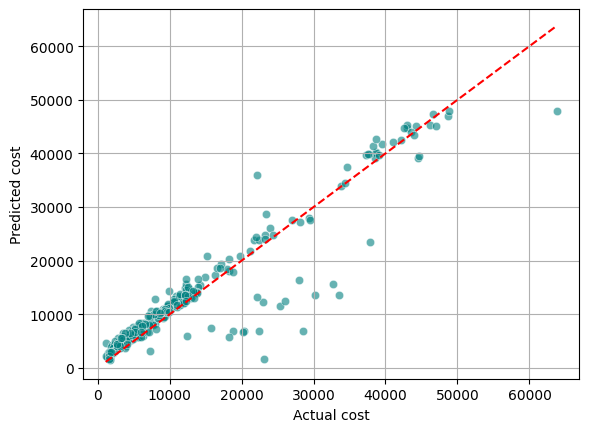

In [16]:
# fit the final model
final_pipe = Pipeline(
        [
            ('preprocessor', preprocessor),
            ('model', best_model_obj)
        ]
    )

final_pipe.fit(x_train,y_train)
y_final_pipe_pred = final_pipe.predict(x_test)


# plot actual vs predicted
plt.Figure(figsize=(8,6))
sns.scatterplot(x=y_test , y=y_final_pipe_pred , alpha=0.6 , color='teal')
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual cost')
plt.ylabel('Predicted cost')
plt.grid(True)
plt.show()

In [17]:
# cross validation

# from sklearn.model_selection import cross_val_score

cv_pipe = Pipeline(
    [
            ('preprocessor', preprocessor),
            ('model', best_model_obj)
        ]
)

cv_score = cross_val_score(cv_pipe , x_train, y_train, cv=5 , scoring='neg_mean_squared_error')
cv_score_rmse= np.sqrt(-cv_score)
print('Score: ', cv_score_rmse)
print('Mean score: ', cv_score_rmse.mean())
print('Std: ',cv_score_rmse.std())

Score:  [4856.31324315 3663.31636188 4827.31207574 5292.34043689 4870.74761786]
Mean score:  4702.0059471028235
Std:  546.8742055024395


In [18]:
# Hyperparameter tuning
param_grid = {
    'model__n_estimators':[100,200],
    'model__max_depth':[None, 10, 20],
    'model__min_samples_split':[2,5]
}

grid_search = GridSearchCV(
    estimator=final_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(x_train,y_train)

print(grid_search.best_score_)
print(grid_search.best_params_)
print(grid_search.best_estimator_)

-5667.233373376201
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                      

In [19]:
# final evaluation 
y_pred = grid_search.best_estimator_.predict(x_test)

print('r2: ', r2_score(y_test, y_pred))
print('rmse: ', np.sqrt(mean_squared_error(y_test, y_pred)))
print('mae: ', mean_absolute_error(y_test, y_pred))

r2:  0.8220255916751896
rmse:  5256.453284337809
mae:  2721.937111108789


In [20]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')